In [ ]:
!pip install torch_geometric

In [4]:
!pip uninstall -y torch torchvision torchaudio torch-scatter torch-sparse torch-cluster pyg-lib
!pip install torch==2.5.1 torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu
!pip install torch-scatter torch-sparse torch-cluster -f https://data.pyg.org/whl/torch-2.5.1+cpu.html
!pip install pyg-lib -f https://data.pyg.org/whl/torch-2.5.1+cpu.html
!pip install --upgrade torch-geometric

Found existing installation: torch 2.10.0+cpu
Uninstalling torch-2.10.0+cpu:
  Successfully uninstalled torch-2.10.0+cpu
Found existing installation: torchvision 0.25.0+cpu
Uninstalling torchvision-0.25.0+cpu:
  Successfully uninstalled torchvision-0.25.0+cpu
Found existing installation: torchaudio 2.10.0+cpu
Uninstalling torchaudio-2.10.0+cpu:
  Successfully uninstalled torchaudio-2.10.0+cpu
Found existing installation: torch_scatter 2.1.2+pt26cpu
Uninstalling torch_scatter-2.1.2+pt26cpu:
  Successfully uninstalled torch_scatter-2.1.2+pt26cpu
Found existing installation: torch_cluster 1.6.3+pt26cpu
Uninstalling torch_cluster-1.6.3+pt26cpu:
  Successfully uninstalled torch_cluster-1.6.3+pt26cpu
Found existing installation: pyg_lib 0.5.0+pt26cpu
Uninstalling pyg_lib-0.5.0+pt26cpu:
  Successfully uninstalled pyg_lib-0.5.0+pt26cpu
Looking in indexes: https://download.pytorch.org/whl/cpu
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 174.6/174.6 MB 70.2 MB/s  0:00:02
INFO: pip is looking at

In [1]:
!pip install pyg-lib -f https://data.pyg.org/whl/torch-2.6.0+cpu.html

Looking in links: https://data.pyg.org/whl/torch-2.6.0+cpu.html


In [1]:
import torch
from sklearn.metrics import roc_auc_score
import torch_geometric as tg
from torch_geometric.data import Data
import matplotlib.pyplot as plt
import networkx as nx
from torch_geometric.utils import to_networkx
from torch_geometric.transforms import RandomLinkSplit
import torch.nn as nn
from torch_geometric.nn import MessagePassing
from torch_geometric.utils import add_self_loops, degree
from link_predictor import LinkPredictor


In [2]:
data = torch.load('bitcoin_adress_split.pt', weights_only=False)
data

Data(edge_index=[2, 69352], edge_attr=[69352, 1], x=[99735, 4])

In [36]:
data.is_undirected()

False

In [33]:
data.has_isolated_nodes()

True

In [32]:
data.has_self_loops()

False

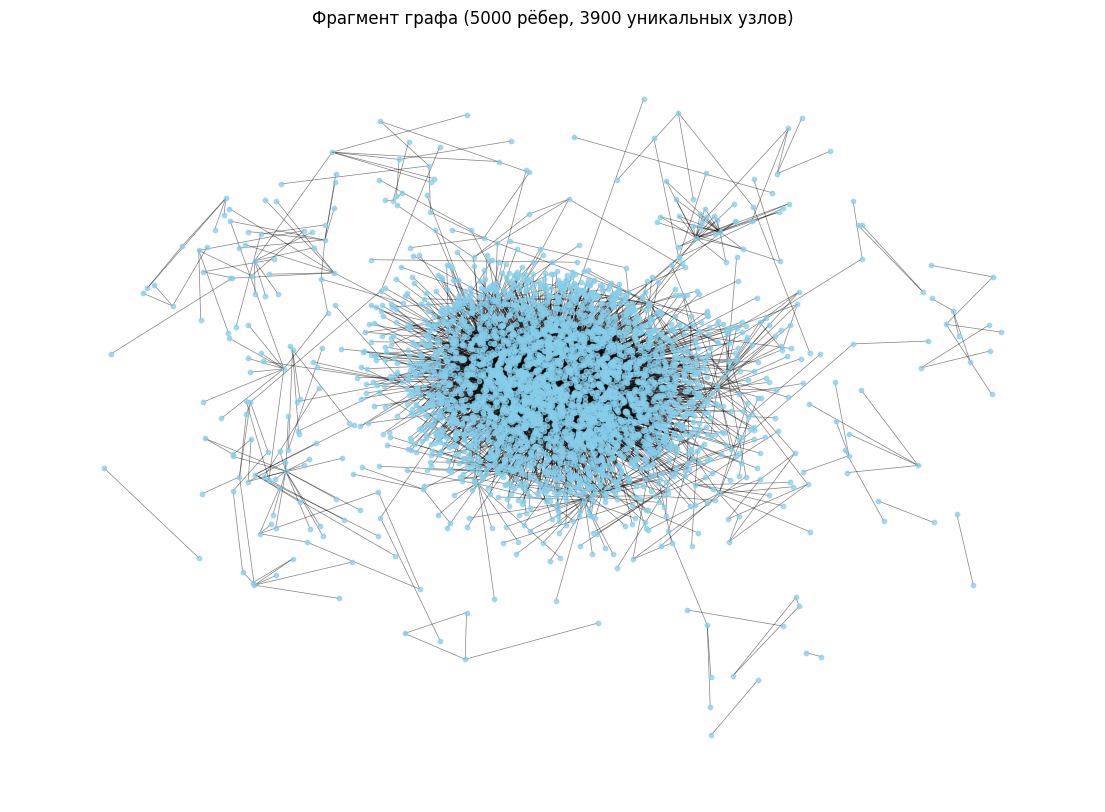

In [29]:
num_edges_to_draw = 5000
edges = data.edge_index[:, :num_edges_to_draw]

unique_nodes, relabeled = torch.unique(edges, return_inverse=True)
relabeled = relabeled.view(2, -1)

sub_data = Data(edge_index=relabeled, num_nodes=len(unique_nodes))

G = to_networkx(sub_data, to_undirected=True)

plt.figure(figsize=(14, 10))
pos = nx.spring_layout(G, k=0.3, seed=42, iterations=50)
nx.draw_networkx_nodes(G, pos, node_size=10, node_color='skyblue', alpha=0.7)
nx.draw_networkx_edges(G, pos, width=0.5, alpha=0.5)
plt.axis('off')
plt.title(f'Фрагмент графа ({num_edges_to_draw} рёбер, {len(unique_nodes)} уникальных узлов)')
plt.savefig('graph_sample.png', dpi=300, bbox_inches='tight')
plt.show()

In [35]:
data['x']

torch.Size([99735, 2])

In [12]:
class SymmetricNormConv(MessagePassing):
    def __init__(self, in_channels, out_channels):
        super().__init__(aggr='add')
        self.lin = nn.Linear(in_channels, out_channels)

    def forward(self, x, edge_index):
        edge_index, _ = add_self_loops(edge_index, num_nodes=x.size(0))
        row, col = edge_index
        deg = degree(row, x.size(0), dtype=x.dtype)
        deg_inv_sqrt = deg.pow(-0.5)
        deg_inv_sqrt[deg_inv_sqrt == float('inf')] = 0
        norm = deg_inv_sqrt[row] * deg_inv_sqrt[col]
        return self.propagate(edge_index, x=x, norm=norm)

    def message(self, x_j, norm):
        return norm.view(-1, 1) * x_j

    def update(self, aggr_out):
        return self.lin(aggr_out)
class SymmetricNormLinkPredictor(nn.Module):
    def __init__(self, in_channels, hidden_channels):
        super().__init__()
        self.conv1 = SymmetricNormConv(in_channels, hidden_channels)
        self.conv2 = SymmetricNormConv(hidden_channels, hidden_channels)
        self.classifier = nn.Sequential(
            nn.Linear(2 * hidden_channels, hidden_channels),
            nn.ReLU(),
            nn.Linear(hidden_channels, 1)
        )

    def forward(self, x, edge_index, edge_label_index, edge_attr=None):
        x = self.conv1(x, edge_index).relu()
        x = self.conv2(x, edge_index)
        src, dst = edge_label_index
        h = torch.cat([x[src], x[dst]], dim=1)
        return self.classifier(h)

device = 'cpu'
data = torch.load('bitcoin_adress_split.pt', weights_only=False)
data = data.to(device)
transform = RandomLinkSplit(
    is_undirected=False,
    num_val=0.1,
    num_test=0.1,
    neg_sampling_ratio=0.5,
)
train_data, val_data, test_data = transform(data)
model = SymmetricNormLinkPredictor(
    in_channels=train_data.num_node_features,
    hidden_channels=64
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
criterion = nn.BCEWithLogitsLoss()

trainer = LinkPredictor(
    model=model,
    optimizer=optimizer,
    criterion=criterion,
    device=device,
    batch_size=1024,
    num_neighbors=[10, 5]
)

trainer.fit(train_data, val_data, epochs=100, verbose=True)
probs = trainer.predict(test_data)
true = test_data.edge_label.cpu().numpy()
auc = roc_auc_score(true, probs)
print(f'Test AUC: {auc:.4f}')

Epoch 001: Train Loss: 1.5913, Val Loss: 750.9951
Epoch 002: Train Loss: 51.0964, Val Loss: 741.0980
Epoch 003: Train Loss: 34.3919, Val Loss: 0.8516
Epoch 004: Train Loss: 0.9800, Val Loss: 0.6920
Epoch 005: Train Loss: 0.7600, Val Loss: 0.6182
Epoch 006: Train Loss: 0.6904, Val Loss: 0.6101
Epoch 007: Train Loss: 0.6679, Val Loss: 0.5906
Epoch 008: Train Loss: 0.6396, Val Loss: 0.5786
Epoch 009: Train Loss: 0.6726, Val Loss: 0.6466
Epoch 010: Train Loss: 0.9080, Val Loss: 3.0821
Epoch 011: Train Loss: 0.8863, Val Loss: 0.6861
Epoch 012: Train Loss: 0.6971, Val Loss: 0.5705
Epoch 013: Train Loss: 0.6097, Val Loss: 0.5599
Epoch 014: Train Loss: 0.5839, Val Loss: 0.5529
Epoch 015: Train Loss: 0.5739, Val Loss: 0.5360
Epoch 016: Train Loss: 0.5596, Val Loss: 0.5288
Epoch 017: Train Loss: 0.5570, Val Loss: 0.5288
Epoch 018: Train Loss: 0.5590, Val Loss: 0.5174
Epoch 019: Train Loss: 0.5518, Val Loss: 0.5297
Epoch 020: Train Loss: 0.5542, Val Loss: 0.5148
Epoch 021: Train Loss: 0.5575, Val

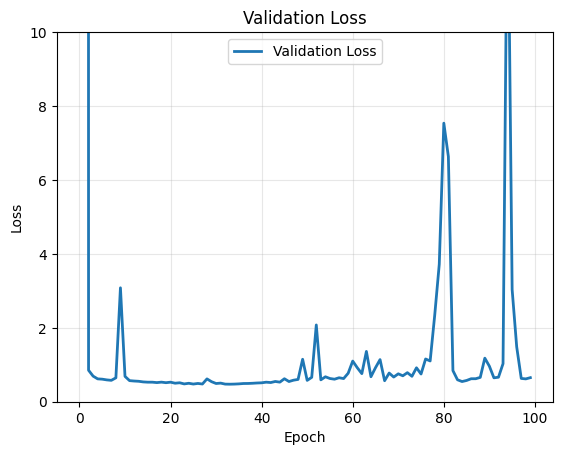

In [13]:
plt.plot(trainer.history['val_loss'], label='Validation Loss', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.ylim(0,10)
plt.title('Validation Loss')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

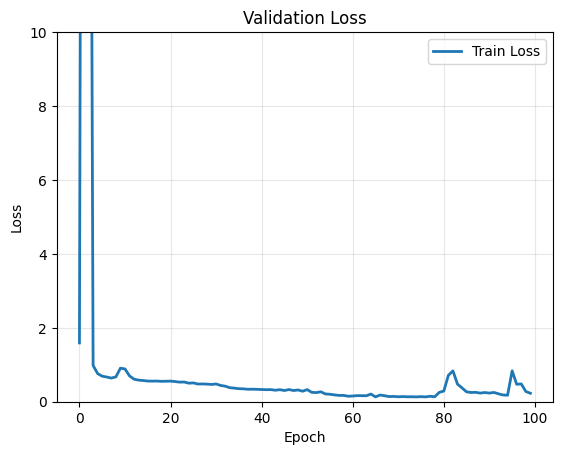

In [14]:
plt.plot(trainer.history['train_loss'], label='Train Loss', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.ylim(0,10)
plt.title('Validation Loss')
plt.legend()
plt.grid(alpha=0.3)
plt.show()